<a href="https://colab.research.google.com/github/sanchi23002/COMPUTER_VISION_WITH_OPENCV_AND_DEEP_LEARNING/blob/main/image_threshoulding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

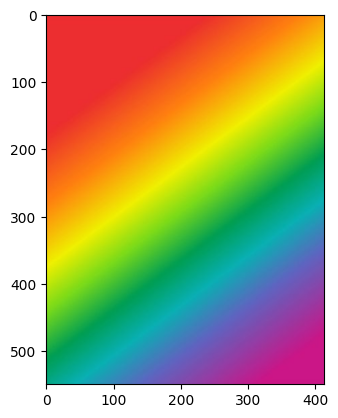

In [ ]:
from PIL import Image
pic = Image.open('rainbow.jpg')
pic1 = np.asarray(pic)
plt.imshow(pic1)

(550, 413)
the maximum value of pixel in this image is  171


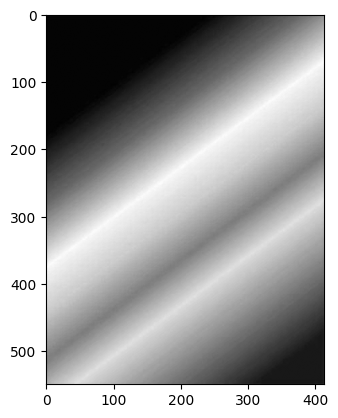

In [ ]:
img = cv2.cvtColor(pic1, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')
print(img.shape)
print("the maximum value of pixel in this image is ",img.max())

255


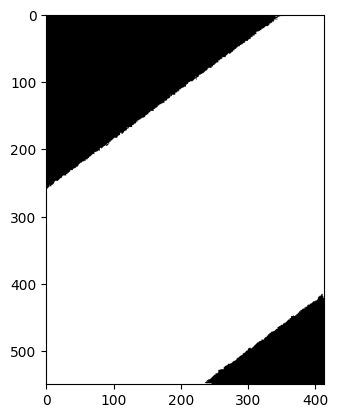

In [ ]:
retval,thresh1 = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)
## cv2.threshold always return 2 value , so you have to assign two variables
## the retval actually the threshould value in floating point , here it is 100.0
## thresh1 is the image
## the logic behind the threshould is:: 255 is max value,below 100 is 0 , and above 100 is 255
plt.imshow(thresh1, cmap = 'gray')
print(thresh1.max())

255


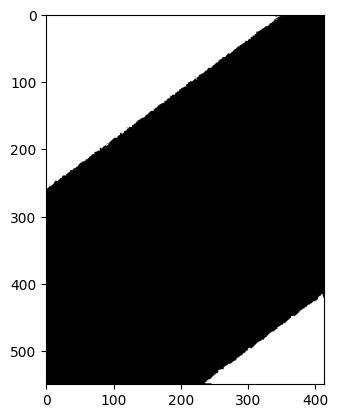

In [ ]:
retval2,thresh2 = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY_INV)#INVERSION OF LOGIC OCCUR
## cv2.threshold always return 2 value , so you have to assign two variables
## the retval actually the threshould value in floating point , here it is 100.0
## thresh1 is the image
## the logic behind the threshould is:: 255 is max value,below 100 is 255 , and above 100 is 0
plt.imshow(thresh2, cmap = 'gray')
print(thresh2.max())

150


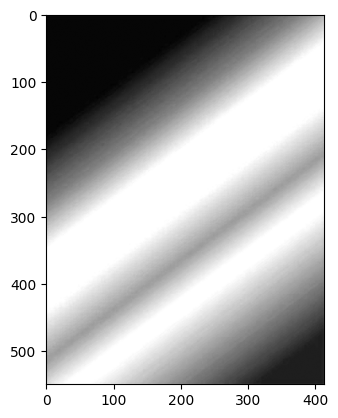

In [ ]:
retval3,thresh3 = cv2.threshold(img, 150,255, cv2.THRESH_TRUNC)
## cv2.threshold always return 2 value , so you have to assign two variables
## the retval actually the threshould value in floating point , here it is 100.0
## thresh1 is the image
## the logic behind the threshould is:: PIXEL>150 ,THEN PIXEL = 150 , IF PIXEL < 150 , THEN KEEP IT AS IT IS
plt.imshow(thresh3, cmap = 'gray')
print(thresh3.max())

171


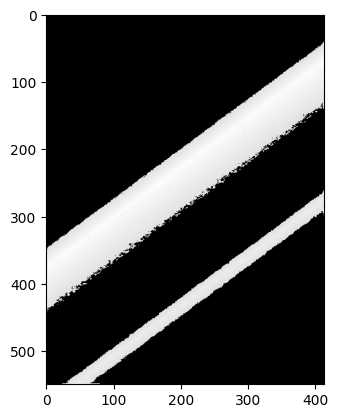

In [ ]:
retval4,thresh4 = cv2.threshold(img, 150,255, cv2.THRESH_TOZERO)
## cv2.threshold always return 2 value , so you have to assign two variables
## the retval actually the threshould value in floating point , here it is 100.0
## thresh1 is the image
## the logic behind the threshould is:: PIXEL>150 ,THEN KEEP AS IT IS , IF PIXEL < 150 , PIXEL =0
plt.imshow(thresh4, cmap = 'gray')
print(thresh4.max())

150


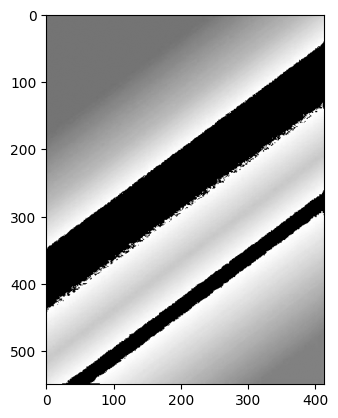

In [ ]:
retval5,thresh5 = cv2.threshold(img, 150,255, cv2.THRESH_TOZERO_INV)
## cv2.threshold always return 2 value , so you have to assign two variables
## the retval actually the threshould value in floating point , here it is 100.0
## thresh1 is the image
## the logic behind the threshould is:: PIXEL>150 ,PIXEL =0 , IF PIXEL < 150 , KEPT IT AS IT IS
plt.imshow(thresh5, cmap = 'gray')
print(thresh5.max())

(839, 532)


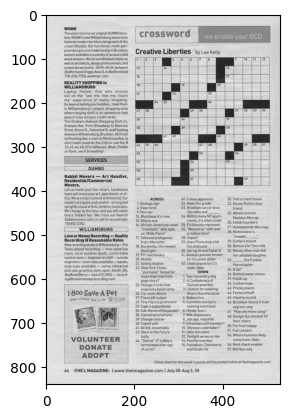

In [ ]:
img2 = cv2.imread('crossword.jpg',0)
plt.imshow(img2, cmap = 'gray')
print(img2.shape)

In [ ]:
def show_pic(new_img):
  fig = plt.figure(figsize=(15,15))
  ax = fig.add_subplot(111)
  ##This adds an Axes object (an individual plot with coordinate axes) inside the figure canvas you just created.
  ##The 111 shorthand: This tells Matplotlib how to position this subplot using a grid system layout:
  ##The first 1: Create a grid with 1 row.
  ##The second 1: Create a grid with 1 column.
  ##The third 1: Put this plot into the 1st cell of that grid.

  ##In short, 111 means: "Give me a single, full-sized plot that takes up the entire 15x15 figure canvas."
  ax.imshow(new_img, cmap = 'gray')

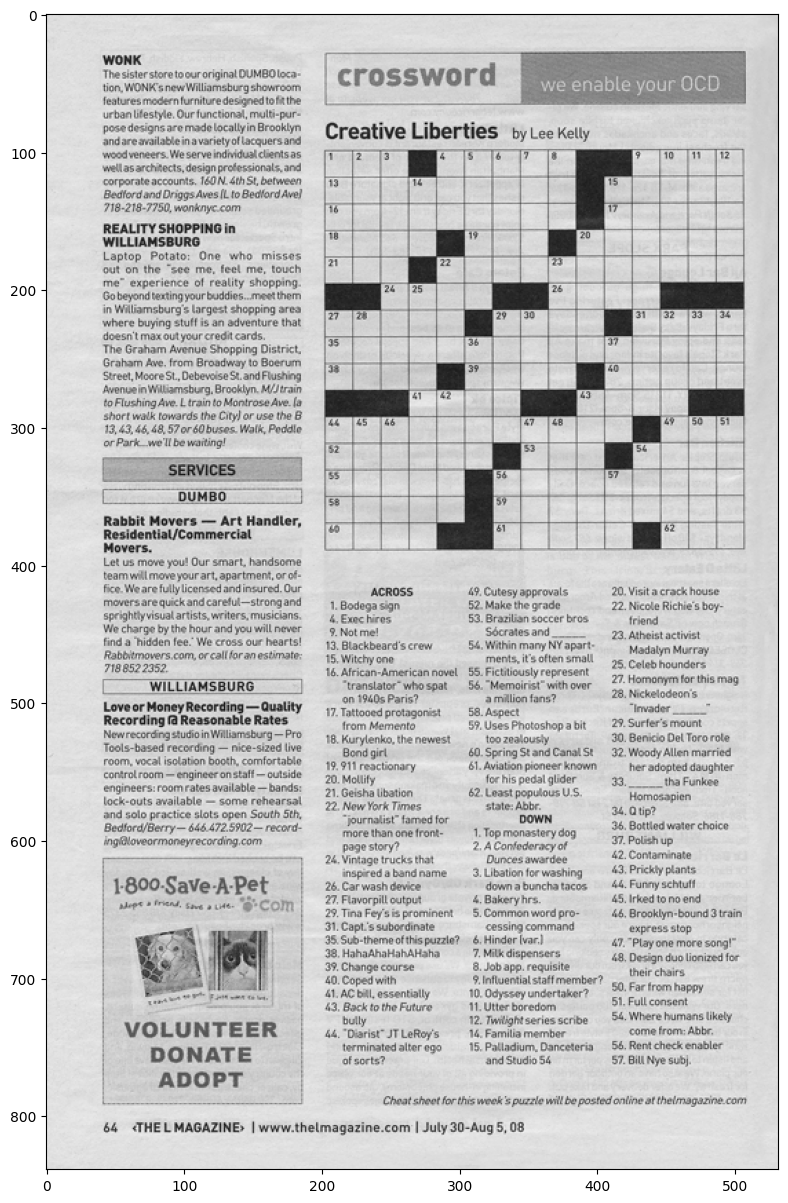

In [ ]:
show_pic(img2)

In [ ]:
img2.max()

np.uint8(255)

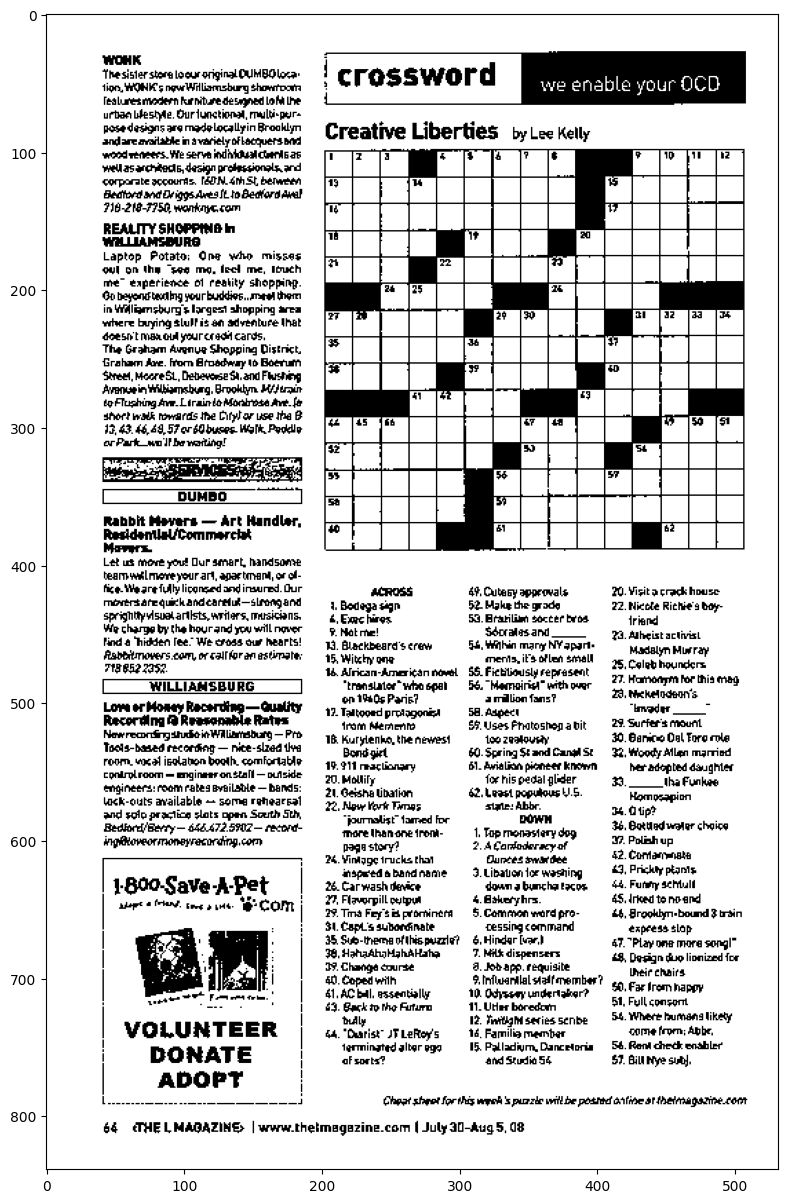

In [ ]:
retval6,thresh6 = cv2.threshold(img2, 170,255, cv2.THRESH_BINARY)
show_pic(thresh6)

In your previous code, you used a global threshold (setting a fixed number like 200 for the entire image). While global thresholding works great if the lighting is perfectly uniform, it fails miserably if the image has shadows or uneven lighting.

Adaptive thresholding fixes this. Instead of using one blanket number for the whole picture, it calculates a unique threshold value for every single pixel based on the lighting of its immediate neighbors. Notice also that cv2.adaptiveThreshold only returns a single value (the image array), so you don't need ret, at the start!

img: The source grayscale image.

255: The maximum value. If a pixel passes the local threshold check, it gets turned into pure white (255).

cv2.ADAPTIVE_THRESH_MEAN_C: This is the mathematical rule used to calculate the threshold for any given pixel.It takes a small box of neighboring pixels around the target pixel and calculates their average (mean) brightness.

cv2THRESH_BINARY: The standard binarization rule. If our target pixel is brighter than its calculated local threshold, it becomes white (255). Otherwise, it becomes black (0).

11 (Block Size): This is the size of the neighborhood box used to calculate the local average. It must be an odd number. Here, it means OpenCV looks at an $11 \times 11$ pixel window centered on the target pixel.

8 (The Constant C): This is a constant number subtracted from the calculated mean.

The Formula: $\text{Local Threshold} = (\text{Mean of } 11\times11 \text{ neighbors}) - C$Subtracting a small constant (like 8) acts as a fine-tuning safety margin. It helps filter out minor background noise or slight gradient variations, keeping text and edges sharp.

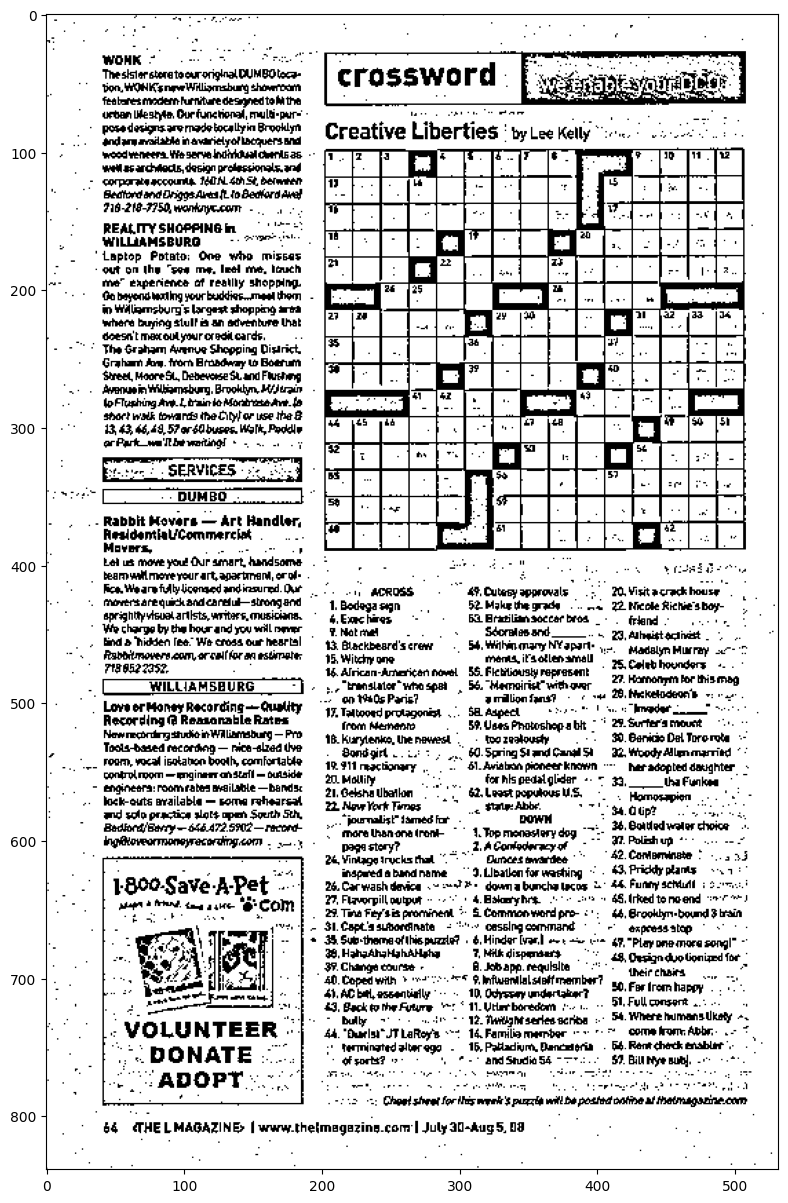

In [ ]:
thresh7 = cv2.adaptiveThreshold(img2, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
show_pic(thresh7)

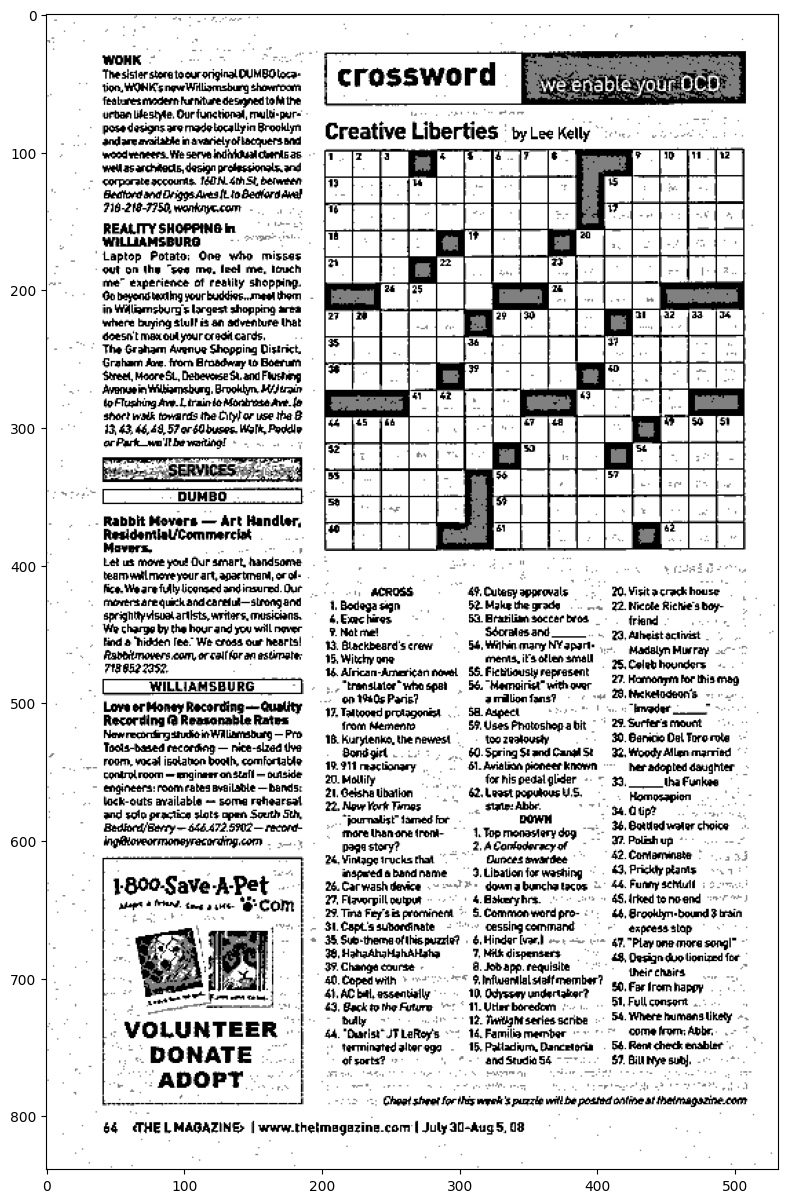

In [ ]:
blended = cv2.addWeighted(thresh6, 0.5, thresh7, 0.5, 0) # pixel = 0.5 * thresh6 + 0.5 * thresh7 + gamma(0)
show_pic(blended)